In [70]:
"""
Analise de empilhamento na interface de bicamadas torcidas de Cs2SnI4.

O que o script faz:
  1. Le um POSCAR (VASP), Cartesian ou Direct, com ou sem "Selective dynamics".
  2. Separa os atomos em 2 camadas (clustering 1D em z, baseado no maior "gap"
     entre posicoes em z, usando os atomos de Sn como referencia robusta dos
     centros de camada).
  3. Define o plano da interface como o ponto medio em z entre o topo da
     camada de baixo e o fundo da camada de cima (usando os atomos de I,
     que sao os atomos terminais de cada camada).
  4. Em cada camada, seleciona os atomos de interface:
       - I de interface: os N_I_camada/4 atomos de I mais proximos do plano
         da interface (1 de 4 planos de I por camada e o de interface).
       - Cs de interface: os N_Cs_camada/2 atomos de Cs mais proximos do
         plano da interface (1 de 2 planos de Cs por camada e o de interface).
  5. Para cada atomo de interface, calcula a distancia ao vizinho mais
     proximo (Cs ou I) pertencente a CAMADA OPOSTA (empilhamento entre
     camadas), respeitando condicoes periodicas de contorno (PBC) nas
     direcoes do plano (a, b) e tambem em c.
  6. Reporta valores medios (+ desvio padrao, min, max, N) para:
       - I(interface) -> Cs mais proximo (camada oposta)
       - I(interface) -> I mais proximo (camada oposta)
       - Cs(interface) -> Cs mais proximo (camada oposta)

Uso:
  python3 analyze_interface_stacking.py POSCAR
  python3 analyze_interface_stacking.py POSCAR --frac-I 0.25 --frac-Cs 0.5
  python3 analyze_interface_stacking.py POSCAR --csv resultados.csv

Dependencias: apenas numpy.
"""
import numpy as np


# --------------------------------------------------------------------------
# 1. Leitura do POSCAR
# --------------------------------------------------------------------------

def read_poscar(path):
    """Le um POSCAR e retorna um dicionario com lattice, species, positions (cartesianas, Angstrom)."""
    with open(path, "r") as f:
        lines = [l.rstrip("\n") for l in f]

    comment = lines[0]
    scale = float(lines[1].strip())
    lattice = np.array([[float(x) for x in lines[i].split()[:3]] for i in (2, 3, 4)])
    if scale < 0:
        # scale negativo = volume da celula em Ang^3 (convencao VASP)
        vol = abs(scale)
        cur_vol = np.abs(np.linalg.det(lattice))
        lattice = lattice * (vol / cur_vol) ** (1.0 / 3.0)
    else:
        lattice = lattice * scale

    line6 = lines[5].split()
    # Linha 6 pode ser nomes das especies (VASP5+) ou contagens (VASP4)
    try:
        counts = [int(x) for x in line6]
        species_names = [f"Elem{i+1}" for i in range(len(counts))]
        idx_next = 6
    except ValueError:
        species_names = line6
        counts = [int(x) for x in lines[6].split()]
        idx_next = 7

    n_atoms = sum(counts)

    mode_line = lines[idx_next].strip()
    selective_dynamics = False
    if mode_line[0].upper() == "S":
        selective_dynamics = True
        idx_next += 1
        mode_line = lines[idx_next].strip()

    is_direct = mode_line[0].upper() in ("D",)
    is_cartesian = mode_line[0].upper() in ("C", "K")
    if not (is_direct or is_cartesian):
        raise ValueError(f"Nao entendi o modo de coordenadas: '{mode_line}'")

    idx_next += 1
    raw_positions = []
    for i in range(n_atoms):
        parts = lines[idx_next + i].split()
        raw_positions.append([float(parts[0]), float(parts[1]), float(parts[2])])
    raw_positions = np.array(raw_positions)

    if is_direct:
        cart_positions = raw_positions @ lattice
    else:
        cart_positions = raw_positions  # Cartesian: ja esta em Angstrom no arquivo

    species = []
    for name, c in zip(species_names, counts):
        species += [name] * c
    species = np.array(species)

    return {
        "comment": comment,
        "lattice": lattice,
        "species": species,
        "positions": cart_positions,  # cartesianas, Angstrom
        "counts": dict(zip(species_names, counts)),
    }


# --------------------------------------------------------------------------
# 2. Distancia minima-imagem (PBC) em coordenadas fracionarias
# --------------------------------------------------------------------------

def min_image_distances(ref_point_cart, candidates_cart, lattice, pbc=(True, True, True)):
    """
    Calcula a distancia minima-imagem entre um ponto e varios candidatos,
    considerando PBC nas direcoes indicadas (a, b, c).
    Retorna array de distancias (Angstrom).
    """
    inv_lat = np.linalg.inv(lattice)
    ref_frac = ref_point_cart @ inv_lat
    cand_frac = candidates_cart @ inv_lat

    delta_frac = cand_frac - ref_frac[None, :]

    for dim in range(3):
        if pbc[dim]:
            delta_frac[:, dim] -= np.round(delta_frac[:, dim])

    delta_cart = delta_frac @ lattice
    dists = np.linalg.norm(delta_cart, axis=1)
    return dists


# --------------------------------------------------------------------------
# 3. Separacao em camadas (clustering 1D por maior gap em z)
# --------------------------------------------------------------------------

def split_layers_by_gap(z_values_ref):
    """
    Dado um array 1D de coordenadas z (de atomos de referencia, ex.: Sn),
    encontra o maior gap e retorna o z de corte (limiar) que separa as
    duas camadas.
    """
    z_sorted = np.sort(z_values_ref)
    gaps = np.diff(z_sorted)
    i_max_gap = np.argmax(gaps)
    z_cut = 0.5 * (z_sorted[i_max_gap] + z_sorted[i_max_gap + 1])
    return z_cut


# --------------------------------------------------------------------------
# 4. Funcao principal de analise
# --------------------------------------------------------------------------

def analyze_interface(poscar_path, frac_I=0.25, frac_Cs=0.5, verbose=True):
    data = read_poscar(poscar_path)
    lattice = data["lattice"]
    species = data["species"]
    pos = data["positions"]

    is_Cs = species == "Cs"
    is_I  = species == "I"
    is_Sn = species == "Sn"

    if not is_Sn.any():
        raise ValueError("Nao encontrei atomos de Sn. Verifique os nomes das especies no POSCAR.")

    # --- separa camadas pelo maior gap em z dos Sn ---
    z_cut = split_layers_by_gap(pos[is_Sn, 2])
    layer_bottom = pos[:, 2] < z_cut

    if verbose:
        print(f"[camadas] z_cut = {z_cut:.3f} A | "
              f"baixo: {layer_bottom.sum()} atomos | cima: {(~layer_bottom).sum()} atomos")

    # --- plano da interface (entre I terminais das duas camadas) ---
    I_bot = is_I &  layer_bottom
    I_top = is_I & ~layer_bottom

    z_top_bot = pos[I_bot, 2].max()
    z_bot_top = pos[I_top, 2].min()
    z_iface   = 0.5 * (z_top_bot + z_bot_top)

    if verbose:
        print(f"[interface] topo camada baixo (I) = {z_top_bot:.3f} A | "
              f"fundo camada cima (I) = {z_bot_top:.3f} A")
        print(f"[interface] z_interface = {z_iface:.3f} A | "
              f"gap vdW = {z_bot_top - z_top_bot:.3f} A")

    # --- seleciona atomos de interface ---
    def select(mask, frac):
        idx = np.where(mask)[0]
        n   = int(round(frac * len(idx)))
        if n == 0:
            return np.array([], dtype=int)
        order = np.argsort(np.abs(pos[idx, 2] - z_iface))
        return idx[order[:n]]

    I_bot_idx  = select(I_bot, frac_I)
    I_top_idx  = select(I_top, frac_I)
    Cs_bot_idx = select(is_Cs &  layer_bottom, frac_Cs)
    Cs_top_idx = select(is_Cs & ~layer_bottom, frac_Cs)

    if verbose:
        print(f"[selecao] I  -> bot={len(I_bot_idx)} (/{I_bot.sum()})  "
              f"top={len(I_top_idx)} (/{I_top.sum()})")
        print(f"[selecao] Cs -> bot={len(Cs_bot_idx)} (/{(is_Cs & layer_bottom).sum()})  "
              f"top={len(Cs_top_idx)} (/{(is_Cs & ~layer_bottom).sum()})")

    # --- distancias vizinho mais proximo na camada oposta ---
    def nearest(src_idx, tgt_idx):
        if len(src_idx) == 0 or len(tgt_idx) == 0:
            return np.array([])
        tgt_pos = pos[tgt_idx]
        return np.array([
            min_image_distances(pos[i], tgt_pos, lattice).min()
            for i in src_idx
        ])

    # I -> Cs (camada oposta)
    d_I_to_Cs = np.concatenate([
        nearest(I_bot_idx, Cs_top_idx),
        nearest(I_top_idx, Cs_bot_idx),
    ])
    # I -> I (camada oposta)
    d_I_to_I = np.concatenate([
        nearest(I_bot_idx, I_top_idx),
        nearest(I_top_idx, I_bot_idx),
    ])
    # Cs -> Cs (camada oposta)
    d_Cs_to_Cs = np.concatenate([
        nearest(Cs_bot_idx, Cs_top_idx),
        nearest(Cs_top_idx, Cs_bot_idx),
    ])

    def summ(arr):
        if len(arr) == 0:
            return dict(n=0, mean=np.nan, std=np.nan, min=np.nan, max=np.nan)
        return dict(n=len(arr), mean=arr.mean(), std=arr.std(),
                    min=arr.min(), max=arr.max())

    # ---- razao por atomo de I: R = 2*d(I->Cs) / (d(I->I) + d(I->Cs)) ----
    # Empilhamos os vetores de I_bot e I_top na mesma ordem que d_I_to_Cs / d_I_to_I
    ratio_per_I = d_I_to_Cs / (d_I_to_I)

    # posicoes XY dos I de interface (mesma ordem: bot depois top)
    xy_I_interface = np.vstack([
        pos[I_bot_idx, :2],
        pos[I_top_idx, :2],
    ])

    # posicoes XY dos Cs de interface (para overlay no plot)
    xy_Cs_interface = np.vstack([
        pos[Cs_bot_idx, :2],
        pos[Cs_top_idx, :2],
    ])

    results = {
        "I_to_Cs":  summ(d_I_to_Cs),
        "I_to_I":   summ(d_I_to_I),
        "Cs_to_Cs": summ(d_Cs_to_Cs),
        "_raw": dict(I_to_Cs=d_I_to_Cs, I_to_I=d_I_to_I, Cs_to_Cs=d_Cs_to_Cs,
                     ratio_per_I=ratio_per_I),
        "_meta": dict(
            z_cut=z_cut, z_interface=z_iface,
            vdw_gap=z_bot_top - z_top_bot,
            n_I_interface=len(I_bot_idx) + len(I_top_idx),
            n_Cs_interface=len(Cs_bot_idx) + len(Cs_top_idx),
            xy_I_interface=xy_I_interface,
            xy_Cs_interface=xy_Cs_interface,
            lattice=lattice,
        ),
    }
    return results


def print_results(results, label=""):
    if label:
        print(f"\n===== Resultados: {label} =====")
    else:
        print(f"\n===== Resultados =====")

    def fmt(d):
        if d["n"] == 0:
            return "  (sem dados)"
        return (f"  N = {d['n']:4d} | media = {d['mean']:.3f} A | "
                f"std = {d['std']:.3f} A | min = {d['min']:.3f} A | max = {d['max']:.3f} A")

    meta = results["_meta"]


def save_csv(results, path, label=""):
    import csv
    rows = []
    for key, pretty in [("I_to_Cs", "I_to_Cs"), ("I_to_I", "I_to_I"), ("Cs_to_Cs", "Cs_to_Cs")]:
        d = results[key]
        rows.append({"structure": label, "pair": pretty, **d})
    write_header = True
    try:
        with open(path, "x", newline=""):
            pass
    except FileExistsError:
        write_header = False
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["structure", "pair", "n", "mean", "std", "min", "max"])
        if write_header:
            writer.writeheader()
        writer.writerows(rows)

In [71]:
# --------------------------------------------------------------------------
# 5. Heatmap continuo da razao de empilhamento
# --------------------------------------------------------------------------

def plot_stacking_heatmap(results, output_path=None, show_atoms=True,
                          grid_pts=300, smoothing=None):
    """
    Plota um heatmap continuo de R(x,y) = 2*d(I->Cs) / (d(I->I) + d(I->Cs)).

    Interpolacao via RBF (scipy) sobre os I da interface.
    Cores divergentes centradas em R=1:
      azul  (R < 1) = I mais proximo de Cs  -> empilhamento I-sobre-Cs
      branco (R = 1) = distancias iguais
      vermelho (R > 1) = I mais proximo de I -> empilhamento I-sobre-I/Cs-sobre-Cs

    Parametros
    ----------
    results    : dict retornado por analyze_interface()
    output_path: caminho para salvar a figura (None = mostrar na tela)
    show_atoms : sobrepoer posicoes dos atomos de interface como pontos
    grid_pts   : resolucao da grade de interpolacao (NxN)
    smoothing  : parametro de suavizacao da RBF (None = automatico)
    """
    from scipy.interpolate import RBFInterpolator
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import matplotlib.patches as mpatches
    from matplotlib.ticker import AutoMinorLocator

    meta  = results["_meta"]
    raw   = results["_raw"]
    ratio = raw["ratio_per_I"]
    xy_I  = meta["xy_I_interface"]
    xy_Cs = meta["xy_Cs_interface"]
    lat   = meta["lattice"]

    # --- vetores de rede no plano (a1, a2) ---
    a1 = lat[0, :2]   # projecao em xy
    a2 = lat[1, :2]

    # --- expande periodicamente os pontos de I para suavizar bordas ---
    # replica em -1,0,+1 nas direcoes a1 e a2
    shifts = np.array([[i, j] for i in (-1, 0, 1) for j in (-1, 0, 1)])
    xy_exp = np.vstack([xy_I + s[0] * a1 + s[1] * a2 for s in shifts])
    r_exp  = np.tile(ratio, len(shifts))

    # --- grade de interpolacao dentro da celula unitaria ---
    # parametros fracionarios de 0 a 1
    frac_u = np.linspace(0, 1, grid_pts)
    frac_v = np.linspace(0, 1, grid_pts)
    Fu, Fv = np.meshgrid(frac_u, frac_v)
    # coordenadas cartesianas da grade
    Xg = Fu * a1[0] + Fv * a2[0]
    Yg = Fu * a1[1] + Fv * a2[1]
    xy_grid = np.column_stack([Xg.ravel(), Yg.ravel()])

    # --- RBF interpolation ---
    eps = smoothing if smoothing is not None else 1.0   # escala de suavizacao
    rbf = RBFInterpolator(xy_exp, r_exp, kernel="thin_plate_spline",
                          smoothing=eps * len(xy_exp))
    R_grid = rbf(xy_grid).reshape(grid_pts, grid_pts)

    # --- colormap divergente centrado em R=1 ---
    cmap = plt.cm.RdBu_r   # vermelho > 1, azul < 1
    vmax = max(abs(ratio - 1.0).max() * 1.05, 0.05) + 1.0
    vmin = 2.0 - vmax                                  # simetrico em torno de 1
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    # --- figura ---
    fig, ax = plt.subplots(figsize=(4, 4))

    # imshow precisa de extent em coordenadas cartesianas;
    # como a celula pode ser obliqua, usamos pcolormesh diretamente
    pc = ax.pcolormesh(Xg, Yg, R_grid,
                       cmap=cmap, norm=norm,
                       shading="gouraud",  # interpolacao suave entre celulas
                       rasterized=True)

    cb = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(r"$R = \frac{2\,d_{I \to Cs}}{d_{I \to I} + d_{I \to Cs}}$",
                 fontsize=13)
    cb.ax.axhline(1.0, color="k", lw=1.2, ls="--")
    cb.ax.tick_params(labelsize=10)

    # --- overlay dos atomos de interface ---
    if show_atoms:
        ax.scatter(xy_I[:, 0], xy_I[:, 1],
                   c=ratio, cmap=cmap, norm=norm,
                   s=30, edgecolors="k", linewidths=0.6,
                   zorder=5, label="I (interface)")
        #ax.legend(loc="lower right", fontsize=9,
                  #framealpha=0.85, edgecolor="gray")

    # --- borda da celula unitaria ---
    corners_frac = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]])
    corners_xy   = corners_frac @ np.vstack([a1, a2])
    ax.plot(corners_xy[:, 0], corners_xy[:, 1],
            "k-", lw=1.0, alpha=0.6)

    # --- anotacoes de texto com valores medios ---
    mean_R = ratio.mean()
    std_R  = ratio.std()
    ax.set_xlabel("x  (Å)", fontsize=11)
    ax.set_ylabel("y  (Å)", fontsize=11)
    ax.tick_params(labelsize=9)
    #ax.xaxis.set_minor_locator(AutoMinorLocator())
    #ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_aspect("equal")
    fig.tight_layout()

    if output_path:
        fig.savefig(output_path, dpi=600, bbox_inches="tight")
        print(f"[heatmap] figura salva em: {output_path}")
    else:
        plt.show()

    plt.close(fig)

In [72]:
m_ = [i for i in range(2, 13)]
n_ = [1]

theta_ = []
ratio_rigid_ = []
ratio_relax_ = []

for m in m_:
    for n in n_:
        cost = (m**2 - n**2)/(m**2 + n**2)

        theta_.append(np.arccos(cost)*(180/np.pi))
        
        results = analyze_interface(f"MACE/{m}_{n}/POSCAR_BASE", frac_I=0.25, frac_Cs=0.5, verbose=False)
        
        ratio_rigid = 2*results['I_to_Cs']['mean']/(results['I_to_I']['mean'] + results['Cs_to_Cs']['mean'])
        
        ratio_rigid_.append(ratio_rigid)
        
        results = analyze_interface(f"MACE/{m}_{n}/POSCAR", frac_I=0.25, frac_Cs=0.5, verbose=False)
        
        ratio_relax = 2*results['I_to_Cs']['mean']/(results['I_to_I']['mean'] + results['Cs_to_Cs']['mean'])
        
        ratio_relax_.append(ratio_relax)

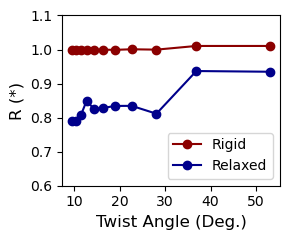

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# separar colunas
distance = np.array(theta_)
potential1 = np.array(ratio_rigid_)
potential2 = np.array(ratio_relax_)

# plot
plt.figure(figsize=(3,2.5))
plt.plot(distance, potential1, color='darkred', marker="o", label="Rigid")
plt.plot(distance, potential2, color='darkblue', marker="o", label="Relaxed")

plt.xlabel("Twist Angle (Deg.)", fontsize=12)
plt.ylabel("R (*)", fontsize=12)

plt.ylim(0.6, 1.1)


plt.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.savefig("Images/Ratio.png", dpi=600)
plt.show()

In [74]:
results = analyze_interface("MACE/13_1/POSCAR", frac_I=0.25, frac_Cs=0.5, verbose=True)

#print(results)

[camadas] z_cut = 17.566 A | baixo: 1190 atomos | cima: 1190 atomos
[interface] topo camada baixo (I) = 16.382 A | fundo camada cima (I) = 18.746 A
[interface] z_interface = 17.564 A | gap vdW = 2.364 A
[selecao] I  -> bot=170 (/680)  top=170 (/680)
[selecao] Cs -> bot=170 (/340)  top=170 (/340)


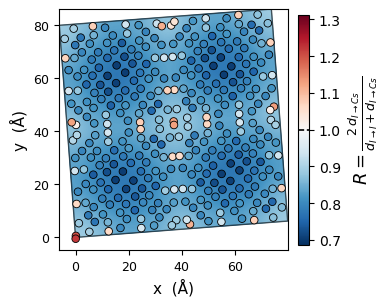

In [75]:
plot_stacking_heatmap(results)